In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
chick = pd.read_csv("chickwts.csv")
means = chick.groupby("feed")["weight"].mean().sort_values(ascending=False)
means

feed
sunflower    328.916667
casein       323.583333
meatmeal     276.909091
soybean      246.428571
linseed      218.750000
horsebean    160.200000
Name: weight, dtype: float64

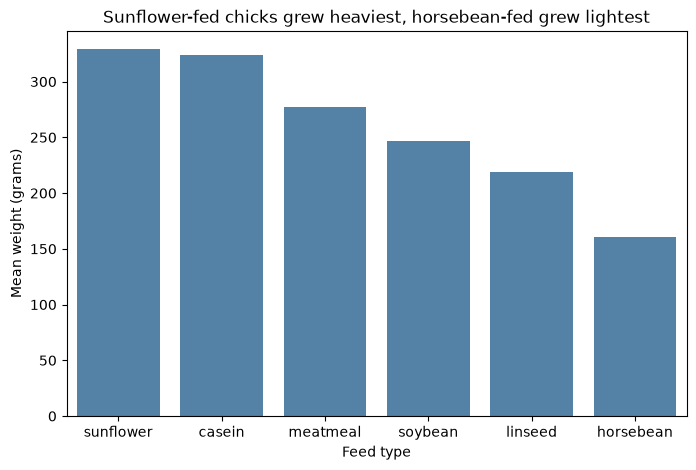

In [3]:
plt.figure(figsize=(8, 5))
sns.barplot(x=means.index, y=means.values, color="steelblue")
plt.title("Sunflower-fed chicks grew heaviest, horsebean-fed grew lightest")
plt.xlabel("Feed type")
plt.ylabel("Mean weight (grams)")
plt.show()

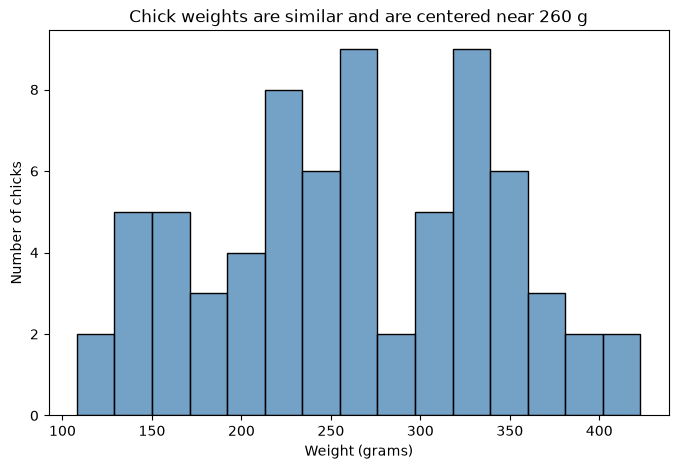

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(chick["weight"], bins=15, color="steelblue")
plt.title("Chick weights are similar and are centered near 260 g")
plt.xlabel("Weight (grams)")
plt.ylabel("Number of chicks")
plt.show()

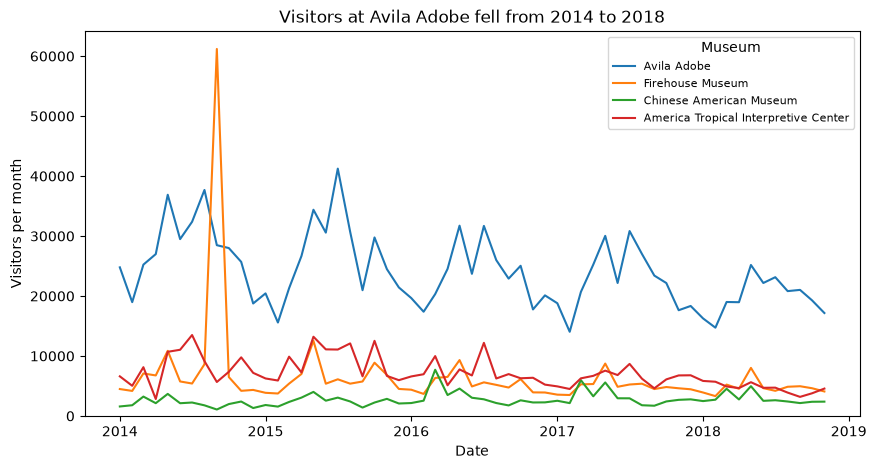

In [5]:
museum = pd.read_csv("museum_visitors.csv")
museum["Date"] = pd.to_datetime(museum["Date"])

long = museum.melt(id_vars="Date", var_name="Museum", value_name="Visitors")

plt.figure(figsize=(10, 5))
sns.lineplot(data=long, x="Date", y="Visitors", hue="Museum")
plt.title("Visitors at Avila Adobe fell from 2014 to 2018")
plt.xlabel("Date")
plt.ylabel("Visitors per month")
plt.ylim(0, None)
plt.legend(title="Museum", fontsize=8)
plt.show()

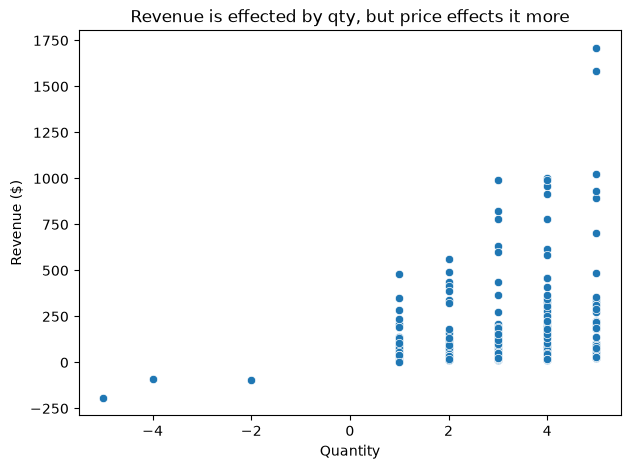

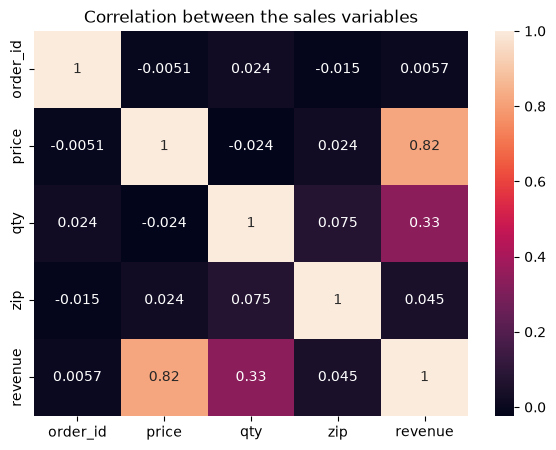

In [6]:
df = pd.read_csv("sales_clean.csv")
df["revenue"] = df["price"] * df["qty"]

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="qty", y="revenue")
plt.title("Revenue is effected by qty, but price effects it more")
plt.xlabel("Quantity")
plt.ylabel("Revenue ($)")
plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation between the sales variables")
plt.show()

In [7]:
#The mean weight of sunflower-fed chicks equals the mean weight of horsebean-fed chicks.

In [8]:
sun = chick[chick["feed"] == "sunflower"]["weight"]
horse = chick[chick["feed"] == "horsebean"]["weight"]

t, p = stats.ttest_ind(sun, horse)
print("difference (g):", sun.mean() - horse.mean())
print("t =", t, " p =", p)

difference (g): 168.7166666666667
t = 8.848346742516636  p = 2.3743507676837164e-08


In [9]:
#Sunflower-fed chicks weighed more than horsebean-fed chicks (t = T, p = P). 
#So I reject the null, but with only 12 and 10 chicks from one farm's data it should not be generalize.

In [10]:
#In my bar chart I started the y-axis at zero so bar heights are proportional to the values.
#I labeled the y-axis with grams and gave it a title that states the takeaway.